# Tasks 1: BERT Baseline for Music Tag Understanding

## 0. Setup — install dependencies

In [ ]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q transformers datasets huggingface_hub librosa scikit-learn matplotlib seaborn joblib soxr tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.8 MB/s eta 0:00:00


In [ ]:
import os, re, math, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import librosa
from datasets import load_dataset
from collections import Counter, defaultdict

from transformers import AutoTokenizer, AutoModel

from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, Batch

from sklearn.metrics import f1_score, average_precision_score, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BERT_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

USE_AMP = DEVICE.type == "cuda"

os.makedirs("results/plots", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## BERT Baseline for Music Tag Understanding

**Goal:** multi-label classifier over text-only context (captions), no graph.

Model: `t = BERT_CLS(text)`, `y_hat_k = sigmoid(w_k^T t + b_k)`, trained with BCE loss per tag.

**Data:** `google/MusicCaps` — real captions + real `aspect_list` tags. We keep the
**top-15** most frequent aspects (down from 50) so Macro-F1 isn't dominated by tags that
appear a handful of times in the whole dataset.

In [ ]:
def load_musiccaps(top_k_tags=15):
    ds = load_dataset("google/MusicCaps", split="train")

    counter = Counter()
    parsed_aspects = []
    for row in ds:
        aspects = [a.strip().lower() for a in row["aspect_list"].strip("[]").replace("'", "").split(",") if a.strip()]
        parsed_aspects.append(aspects)
        counter.update(aspects)
    vocab = [t for t, _ in counter.most_common(top_k_tags)]
    tag2idx = {t: i for i, t in enumerate(vocab)}

    examples = []
    for row, aspects in zip(ds, parsed_aspects):
        labels = np.zeros(len(vocab), dtype=np.float32)
        for a in aspects:
            if a in tag2idx:
                labels[tag2idx[a]] = 1.0
        if labels.sum() > 0:
            examples.append({"text": row["caption"], "labels": labels, "aspects": aspects})
    return examples, vocab, ds

tag_examples, tag_vocab, musiccaps_ds = load_musiccaps(top_k_tags=15)
print(f"Loaded {len(tag_examples)} caption examples, {len(tag_vocab)} tags")
print("Tags:", tag_vocab)

README.md:   0%|          | 0.00/5.06k [00:00<?, ?B/s]

musiccaps-public.csv: reconstructing file:   0%|          |  0.00B / 2.94MB            

musiccaps-public.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5521 [00:00<?, ? examples/s]

Loaded 4243 caption examples, 15 tags
Tags: ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo', 'acoustic drums', 'fast tempo', 'mono', 'groovy', 'bass guitar']


In [ ]:
class TagDataset(Dataset):
    def __init__(self, examples, tokenizer, max_len=128):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        enc = self.tokenizer(ex["text"], truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(ex["labels"]),
        }

random.shuffle(tag_examples)
split = int(0.85 * len(tag_examples))
train_ds = TagDataset(tag_examples[:split], tokenizer)
val_ds = TagDataset(tag_examples[split:], tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

Train: 3606  Val: 637


In [ ]:
class BertTagger(nn.Module):
    def __init__(self, bert_name, num_tags, freeze_bert=False):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_name)
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        hidden = self.bert.config.hidden_size
        self.head = nn.Linear(hidden, num_tags)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.head(cls)
        return logits, cls

bert_tagger = BertTagger(BERT_NAME, num_tags=len(tag_vocab)).to(DEVICE)
optimizer = torch.optim.AdamW(bert_tagger.parameters(), lr=2e-5)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def run_epoch_bert(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with torch.set_grad_enabled(train_mode):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits, _ = model(input_ids, attn)
                loss = F.binary_cross_entropy_with_logits(logits, labels)
            if train_mode:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * labels.size(0)
        all_logits.append(logits.detach().float().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()
    preds = (1 / (1 + np.exp(-all_logits))) > 0.5
    macro_f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, preds, average="micro", zero_division=0)
    return total_loss / len(loader.dataset), macro_f1, micro_f1

EPOCHS_TASK1 = 10
history = {"val_macro_f1": [], "val_micro_f1": []}
best_f1, best_state = -1, None
for epoch in range(EPOCHS_TASK1):
    tr_loss, tr_f1, tr_mf1 = run_epoch_bert(bert_tagger, train_loader, optimizer)
    val_loss, val_f1, val_mf1 = run_epoch_bert(bert_tagger, val_loader)
    history["val_macro_f1"].append(val_f1)
    history["val_micro_f1"].append(val_mf1)
    print(f"[Task1] epoch {epoch+1}: train_macroF1={tr_f1:.3f} val_macroF1={val_f1:.3f} val_microF1={val_mf1:.3f}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().clone() for k, v in bert_tagger.state_dict().items()}

bert_tagger.load_state_dict(best_state)
print(f"Best Task 1 val Macro-F1: {best_f1:.4f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Task1] epoch 1: train_macroF1=0.334 val_macroF1=0.617 val_microF1=0.716
[Task1] epoch 2: train_macroF1=0.693 val_macroF1=0.803 val_microF1=0.827
[Task1] epoch 3: train_macroF1=0.799 val_macroF1=0.828 val_microF1=0.850
[Task1] epoch 4: train_macroF1=0.828 val_macroF1=0.827 val_microF1=0.845
[Task1] epoch 5: train_macroF1=0.857 val_macroF1=0.833 val_microF1=0.852
[Task1] epoch 6: train_macroF1=0.873 val_macroF1=0.840 val_microF1=0.856
[Task1] epoch 7: train_macroF1=0.898 val_macroF1=0.827 val_microF1=0.845
[Task1] epoch 8: train_macroF1=0.920 val_macroF1=0.830 val_microF1=0.847
[Task1] epoch 9: train_macroF1=0.937 val_macroF1=0.830 val_microF1=0.843
[Task1] epoch 10: train_macroF1=0.955 val_macroF1=0.823 val_microF1=0.841
Best Task 1 val Macro-F1: 0.8401


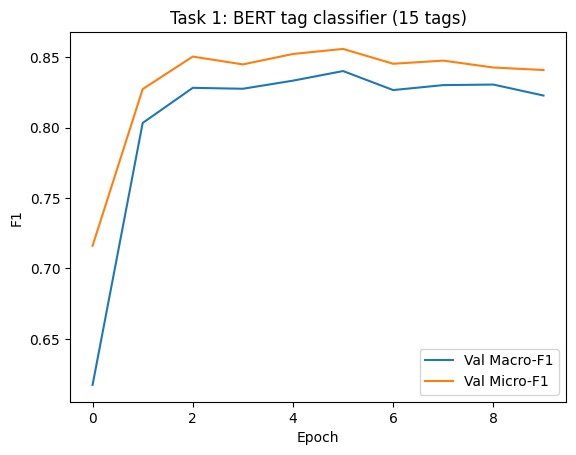

TEXT: The song is an acapella cover of a game theme song. The song is medium tempo wit...
  TRUE: ['medium tempo', 'amateur recording']
  PRED (top5): ['medium tempo', 'emotional', 'passionate', 'amateur recording', 'groovy']

TEXT: The low quality recording features a children song that consists a passionate fe...
  TRUE: ['low quality']
  PRED (top5): ['low quality', 'noisy', 'energetic', 'mono', 'live performance']

TEXT: A male singer sings this vocals with a vocoder. The song is medium tempo with a ...
  TRUE: ['passionate', 'medium tempo', 'energetic']
  PRED (top5): ['passionate', 'medium tempo', 'emotional', 'energetic', 'groovy']

TEXT: This is the recording of a DJ performance. In the rhythmic background, the elect...
  TRUE: ['groovy']
  PRED (top5): ['groovy', 'instrumental', 'energetic', 'amateur recording', 'bass guitar']

TEXT: A female vocalist sings this soft melody. The tempo is slow with acoustic guitar...
  TRUE: ['slow tempo']
  PRED (top5): ['slow tempo', 'amateur

In [ ]:
plt.plot(history["val_macro_f1"], label="Val Macro-F1")
plt.plot(history["val_micro_f1"], label="Val Micro-F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend(); plt.title("Task 1: BERT tag classifier (15 tags)")
plt.savefig("results/plots/task1_f1_curves.png", dpi=120, bbox_inches="tight")
plt.show()

bert_tagger.eval()
for i in range(5):
    ex = val_ds.examples[i]
    enc = tokenizer(ex["text"], truncation=True, padding="max_length", max_length=128, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits, _ = bert_tagger(enc["input_ids"], enc["attention_mask"])
    probs = torch.sigmoid(logits).float().cpu().numpy()[0]
    top_pred = [tag_vocab[j] for j in probs.argsort()[-5:][::-1]]
    true_tags = [tag_vocab[j] for j, v in enumerate(ex["labels"]) if v == 1]
    print(f"TEXT: {ex['text'][:80]}...")
    print(f"  TRUE: {true_tags}")
    print(f"  PRED (top5): {top_pred}\n")